In [3]:
# Standard Kaggle setup imports
import numpy as np 
import pandas as pd 
import os

print("Available directories in /kaggle/input:")
for dirname, dirs, filenames in os.walk('/kaggle/input'):
    for dir_name in dirs:
        print(os.path.join(dirname, dir_name))
    break 

Available directories in /kaggle/input:
/kaggle/input/datasets


Found CSV at: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/train.csv
Found Images at: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake
--------------------------------------------------
Generating Spectral Heatmaps.


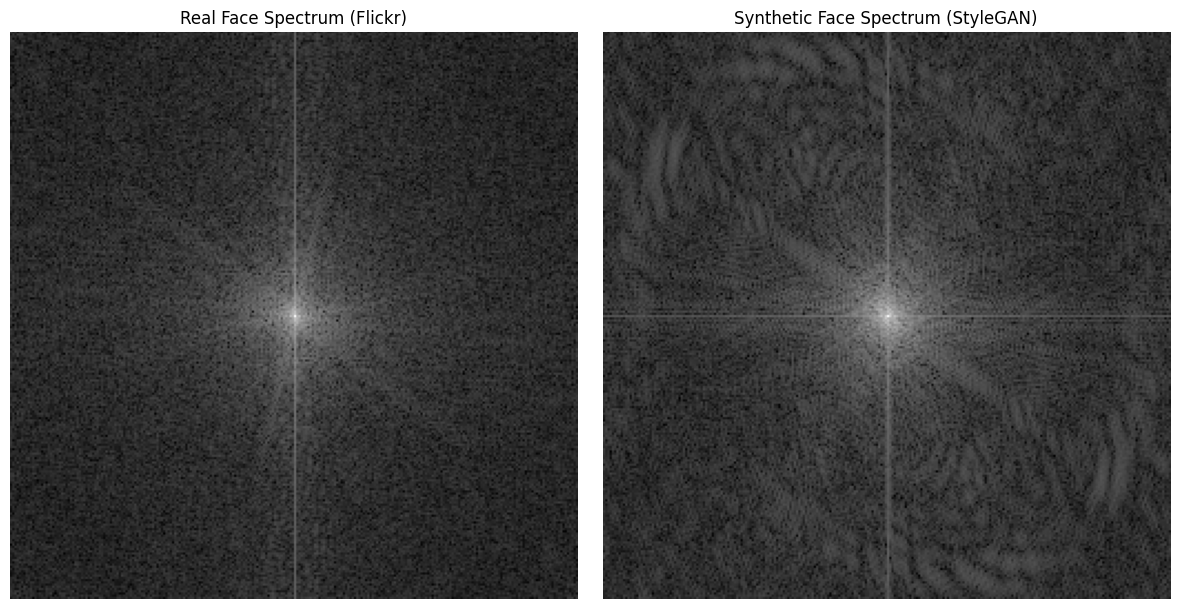

In [4]:
import os
import pandas as pd
import torch
import torch.fft
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

base_dir = '/kaggle/input/'
csv_path = ''
img_base_dir = ''

for root, dirs, files in os.walk(base_dir):
    if 'train.csv' in files:
        csv_path = os.path.join(root, 'train.csv')
        break

for root, dirs, files in os.walk(base_dir):
    if 'train' in dirs and os.path.exists(os.path.join(root, 'train', 'fake')):
        img_base_dir = root
        break

print(f"Found CSV at: {csv_path}")
print(f"Found Images at: {img_base_dir}")
print("-" * 50)

def visualize_spectrum_from_csv(csv_filepath, img_root):
    df = pd.read_csv(csv_filepath)
    
   
    real_path_rel = df[df['label'] == 0].iloc[0]['path']
    fake_path_rel = df[df['label'] == 1].iloc[0]['path']
    
    real_img_path = os.path.join(img_root, real_path_rel)
    fake_img_path = os.path.join(img_root, fake_path_rel)
    
    transform = transforms.Compose([
        transforms.Resize((256, 256)), 
        transforms.ToTensor()
    ])

    real_img = transform(Image.open(real_img_path).convert('L'))
    fake_img = transform(Image.open(fake_img_path).convert('L'))
    
    def get_spectrum(tensor):
        f_shift = torch.fft.fftshift(torch.fft.fft2(tensor))
        mag = 20 * torch.log10(torch.abs(f_shift) + 1)
        return mag[0].numpy()
        
    real_spec = get_spectrum(real_img)
    fake_spec = get_spectrum(fake_img)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(real_spec, cmap='gray')
    axes[0].set_title('Real Face Spectrum (Flickr)')
    axes[0].axis('off')
    
    axes[1].imshow(fake_spec, cmap='gray')
    axes[1].set_title('Synthetic Face Spectrum (StyleGAN)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

if csv_path != '' and img_base_dir != '':
    print("Generating Spectral Heatmaps.")
    visualize_spectrum_from_csv(csv_path, img_base_dir)
else:
    print("Could not find CSV or Image directories.")

In [11]:
#NEW APPROACH I'VE STARTED FROM HERE
import os
import pandas as pd
import numpy as np
import cv2
import face_recognition 
from tqdm import tqdm

base_input = '/kaggle/input'
csv_path = ""
img_base_dir = ""

for root, dirs, files in os.walk(base_input):
    if 'train.csv' in files and not csv_path:
        csv_path = os.path.join(root, 'train.csv')
   
    if 'train' in dirs and 'real_vs_fake' in root:
        test_path = os.path.join(root, 'train')
        if os.path.exists(test_path) and 'fake' in os.listdir(test_path):
            img_base_dir = root

print(f"Verified CSV Path: {csv_path}")
print(f"Verified Image Root: {img_base_dir}")
print("-" * 50)

if not csv_path or not img_base_dir:
    raise SystemExit("Path discovery failed. Please ensure the dataset is properly attached.")

print("Structural Pre-processing Step")

df = pd.read_csv(csv_path)

df_real = df[df['label'] == 0].head(5000)
df_fake = df[df['label'] == 1].head(5000)
df_subset = pd.concat([df_real, df_fake]).reset_index(drop=True)

ratios = []
valid_indices = []

for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
    img_path = os.path.join(img_base_dir, row['path'])
    image = cv2.imread(img_path)
    
    if image is None: 
        continue 
    
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_landmarks_list = face_recognition.face_landmarks(rgb_image)
    
    if face_landmarks_list:
        landmarks = face_landmarks_list[0]
        left_eye = np.mean(landmarks['left_eye'], axis=0)
        right_eye = np.mean(landmarks['right_eye'], axis=0)
        nose_bridge = np.array(landmarks['nose_bridge'][0])
        nose_tip = np.array(landmarks['nose_tip'][2])
        
        eye_dist = np.linalg.norm(right_eye - left_eye)
        nose_len = np.linalg.norm(nose_bridge - nose_tip)
        
        ratios.append(eye_dist / (nose_len + 1e-6))
        valid_indices.append(idx)

df_valid = df_subset.iloc[valid_indices].copy()
df_valid['ratio'] = ratios

real_ratios = df_valid[df_valid['label'] == 0]['ratio']
mu, sigma = real_ratios.mean(), real_ratios.std()
df_valid['structural_delta'] = np.abs((df_valid['ratio'] - mu) / sigma)

NEW_CSV_PATH = '/kaggle/working/train_with_landmarks_10k.csv'
df_valid.to_csv(NEW_CSV_PATH, index=False)

print(f"\nBaseline μ: {mu:.4f}, σ: {sigma:.4f}")
print(f"Dataset saved: {NEW_CSV_PATH} ({len(df_valid)} faces found)")

Verified CSV Path: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/train.csv
Verified Image Root: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake
--------------------------------------------------
Structural Pre-processing Step


100%|██████████| 10000/10000 [07:32<00:00, 22.08it/s]



Baseline μ: 1.2556, σ: 0.1090
Dataset saved: /kaggle/working/train_with_landmarks_10k.csv (9973 faces found)


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from torch.amp import GradScaler, autocast
from PIL import Image
import time
import pandas as pd
import os
import random
import numpy as np


class TriStreamDataset(Dataset):
    def __init__(self, csv_file, root_dir, augment=False):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.augment = augment
        
        self.spatial_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.spectral_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

    def __len__(self): return len(self.annotations)

    def apply_fft(self, image_tensor):
        f_transform = torch.fft.fft2(image_tensor)
        f_shift = torch.fft.fftshift(f_transform)
        magnitude_spectrum = torch.log(torch.abs(f_shift) + 1e-6)
        
        mag_min, mag_max = magnitude_spectrum.min(), magnitude_spectrum.max()
        magnitude_spectrum = (magnitude_spectrum - mag_min) / (mag_max - mag_min + 1e-8)
        
        if self.augment and random.random() > 0.5:
            magnitude_spectrum = torch.flip(magnitude_spectrum, dims=[-1])
            
        return magnitude_spectrum

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[idx]['path'])
       
        image_rgb = Image.open(img_path).convert('RGB')
        image_gray = image_rgb.convert('L')

        spatial_tensor = self.spatial_transform(image_rgb)
       
        spectral_raw = self.spectral_transform(image_gray)
        spectral_tensor = self.apply_fft(spectral_raw)

        delta = torch.tensor([self.annotations.iloc[idx]['structural_delta']], dtype=torch.float32)
        label = torch.tensor([self.annotations.iloc[idx]['label']], dtype=torch.float32)
        
        return spatial_tensor, spectral_tensor, delta, label

class TriStreamFusionNet(nn.Module):
    def __init__(self):
        super(TriStreamFusionNet, self).__init__()
   
        self.spatial_net = models.efficientnet_b0(weights='IMAGENET1K_V1')
        num_spatial_ftrs = self.spatial_net.classifier[1].in_features
        self.spatial_net.classifier = nn.Identity()
        
        self.spectral_net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        num_spectral_ftrs = 64
        
    
        total_features = num_spatial_ftrs + num_spectral_ftrs + 1 # 1280 + 64 + 1 = 1345
        
        self.classifier = nn.Sequential(
            nn.Linear(total_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, spatial, spectral, delta):
        spatial_ftrs = self.spatial_net(spatial)
        spectral_ftrs = self.spectral_net(spectral)
        
        combined = torch.cat((spatial_ftrs, spectral_ftrs, delta), dim=1)
        return self.classifier(combined)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = '/kaggle/working/train_with_landmarks_10k.csv'

train_dataset = TriStreamDataset(CSV_PATH, img_base_dir, augment=True)
val_dataset = TriStreamDataset(CSV_PATH, img_base_dir, augment=False)

indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int(0.2 * len(indices))
train_idx, val_idx = indices[split:], indices[:split]

train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=16, shuffle=True)
val_loader = DataLoader(Subset(val_dataset, val_idx), batch_size=16, shuffle=False)

model = TriStreamFusionNet().to(DEVICE)

optimizer = optim.AdamW([
    {'params': model.spatial_net.parameters(), 'lr': 1e-5},    
    {'params': model.spectral_net.parameters(), 'lr': 1e-4},   
    {'params': model.classifier.parameters(), 'lr': 3e-4}      
], weight_decay=0.01)

criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler('cuda')

print(f"Training Started | Train: {len(train_idx)} | Val: {len(val_idx)}")
best_val_acc = 0.0

for epoch in range(25):
    start = time.time()
    
    # Training
    model.train()
    t_correct, t_total = 0, 0
    for spatial, spectral, delta, label in train_loader:
        spatial, spectral, delta, label = spatial.to(DEVICE), spectral.to(DEVICE), delta.to(DEVICE), label.to(DEVICE)
        
        optimizer.zero_grad()
        with autocast('cuda'):
            outputs = model(spatial, spectral, delta)
            loss = criterion(outputs, label * 0.9 + 0.05)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        t_correct += ((torch.sigmoid(outputs) > 0.5).float() == label).sum().item()
        t_total += label.size(0)

    # Validation
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for spatial, spectral, delta, label in val_loader:
            spatial, spectral, delta, label = spatial.to(DEVICE), spectral.to(DEVICE), delta.to(DEVICE), label.to(DEVICE)
            with autocast('cuda'):
                outputs = model(spatial, spectral, delta)
            v_correct += ((torch.sigmoid(outputs) > 0.5).float() == label).sum().item()
            v_total += label.size(0)

    val_acc = 100 * v_correct / v_total
    print(f"Epoch {epoch+1:02d} | Train: {100*t_correct/t_total:.2f}% | Val: {val_acc:.2f}% | Time: {time.time()-start:.1f}s")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_tristream.pth')

print(f"\nFinal Peak Validation Accuracy: {best_val_acc:.2f}%")

Training Started | Train: 7979 | Val: 1994
Epoch 01 | Train: 77.34% | Val: 85.56% | Time: 75.2s
Epoch 02 | Train: 87.12% | Val: 90.22% | Time: 74.2s
Epoch 03 | Train: 91.03% | Val: 91.32% | Time: 74.2s
Epoch 04 | Train: 92.77% | Val: 93.33% | Time: 74.2s
Epoch 05 | Train: 94.30% | Val: 94.53% | Time: 73.7s
Epoch 06 | Train: 95.53% | Val: 94.63% | Time: 72.9s
Epoch 07 | Train: 95.76% | Val: 95.59% | Time: 73.5s
Epoch 08 | Train: 96.54% | Val: 95.54% | Time: 72.8s
Epoch 09 | Train: 97.48% | Val: 96.39% | Time: 73.3s
Epoch 10 | Train: 97.63% | Val: 95.09% | Time: 73.5s
Epoch 11 | Train: 97.72% | Val: 96.49% | Time: 73.9s
Epoch 12 | Train: 98.16% | Val: 96.64% | Time: 73.6s
Epoch 13 | Train: 97.68% | Val: 96.79% | Time: 76.2s
Epoch 14 | Train: 98.28% | Val: 96.59% | Time: 73.9s
Epoch 15 | Train: 98.17% | Val: 97.14% | Time: 72.6s
Epoch 16 | Train: 98.56% | Val: 97.04% | Time: 73.7s
Epoch 17 | Train: 98.55% | Val: 97.14% | Time: 74.2s
Epoch 18 | Train: 98.61% | Val: 97.19% | Time: 72.9s
Epo

Loading the best Tri-Stream model for evaluation...
Running inference on Validation Set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Real (0)       0.98      0.97      0.98      1016
    Fake (1)       0.97      0.98      0.98       978

    accuracy                           0.98      1994
   macro avg       0.98      0.98      0.98      1994
weighted avg       0.98      0.98      0.98      1994



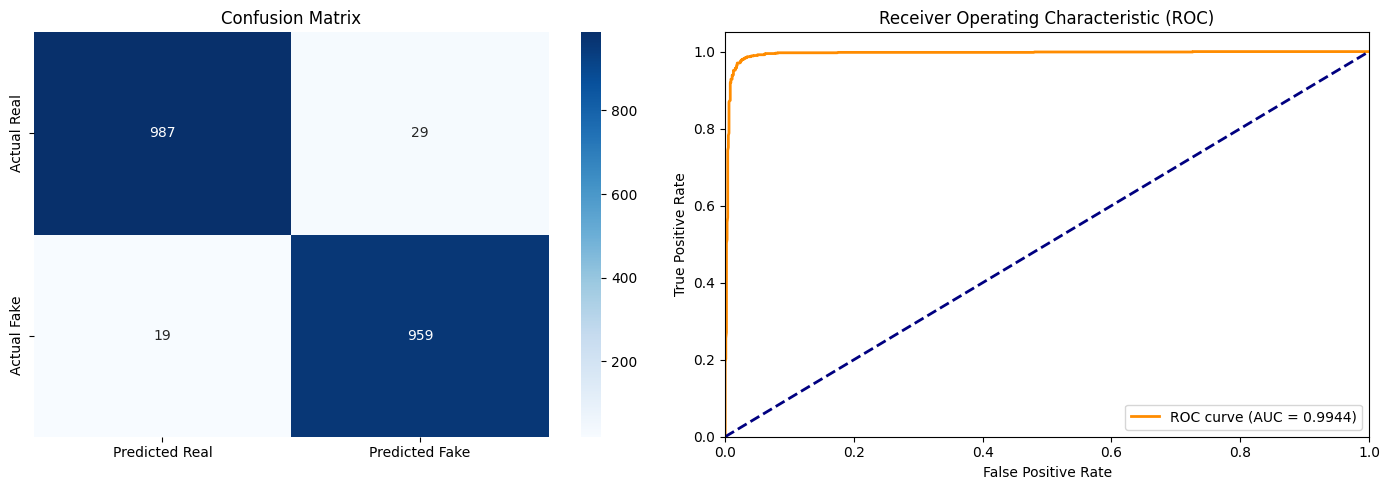

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from torch.amp import autocast

print("Loading the best Tri-Stream model for evaluation...")

model = TriStreamFusionNet().to(DEVICE)
model.load_state_dict(torch.load('best_tristream.pth'))
model.eval()

all_labels = []
all_preds = []
all_probs = []

print("Running inference on Validation Set...")

with torch.no_grad():
    for spatial, spectral, delta, labels in val_loader:
        spatial = spatial.to(DEVICE)
        spectral = spectral.to(DEVICE)
        delta = delta.to(DEVICE)
        labels = labels.to(DEVICE)
        
        with autocast('cuda'):
            outputs = model(spatial, spectral, delta)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(float)
            
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels).flatten()
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
axes[0].set_title('Confusion Matrix')

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [15]:
import os
import pandas as pd
import numpy as np
import cv2
import face_recognition
from tqdm import tqdm
import torch
from torch.amp import autocast
from sklearn.metrics import classification_report

print("--- Preparing Unseen test data ---")
test_csv_path = csv_path.replace('train.csv', 'test.csv')

df_test = pd.read_csv(test_csv_path)
df_test_real = df_test[df_test['label'] == 0].head(1000)
df_test_fake = df_test[df_test['label'] == 1].head(1000)
df_test_subset = pd.concat([df_test_real, df_test_fake]).reset_index(drop=True)

ratios = []
valid_indices = []

for idx, row in tqdm(df_test_subset.iterrows(), total=len(df_test_subset), desc="Extracting Test Landmarks"):
    img_path = os.path.join(img_base_dir, row['path'])
    image = cv2.imread(img_path)
    if image is None: continue
    
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_landmarks_list = face_recognition.face_landmarks(rgb_image)
    
    if face_landmarks_list:
        landmarks = face_landmarks_list[0]
        left_eye = np.mean(landmarks['left_eye'], axis=0)
        right_eye = np.mean(landmarks['right_eye'], axis=0)
        nose_bridge = np.array(landmarks['nose_bridge'][0])
        nose_tip = np.array(landmarks['nose_tip'][2])
        
        eye_dist = np.linalg.norm(right_eye - left_eye)
        nose_len = np.linalg.norm(nose_bridge - nose_tip)
        ratios.append(eye_dist / (nose_len + 1e-6))
        valid_indices.append(idx)

df_test_valid = df_test_subset.iloc[valid_indices].copy()
df_test_valid['ratio'] = ratios

df_test_valid['structural_delta'] = np.abs((df_test_valid['ratio'] - mu) / sigma)

TEST_CSV = '/kaggle/working/test_with_landmarks_2k.csv'
df_test_valid.to_csv(TEST_CSV, index=False)
print(f"\nTest data saved: {len(df_test_valid)} faces verified.")


print("\n--- runnning inference on unseen test set ---")
test_dataset = TriStreamDataset(TEST_CSV, img_base_dir, augment=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for spatial, spectral, delta, labels in tqdm(test_loader, desc="Evaluating Model"):
        spatial, spectral, delta = spatial.to(DEVICE), spectral.to(DEVICE), delta.to(DEVICE)
        
        with autocast('cuda'):
            outputs = model(spatial, spectral, delta)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        
        test_preds.extend(preds)
        test_labels.extend(labels.numpy())

print("\n" + "="*50)
print("Final UNSEEN TEST SET REPORT")
print("="*50)
print(classification_report(test_labels, test_preds, target_names=['Real (0)', 'Fake (1)']))

--- Preparing Unseen test data ---


Extracting Test Landmarks: 100%|██████████| 2000/2000 [01:39<00:00, 20.05it/s]



Test data saved: 1996 faces verified.

--- runnning inference on unseen test set ---


Evaluating Model: 100%|██████████| 125/125 [00:11<00:00, 10.83it/s]


Final UNSEEN TEST SET REPORT
              precision    recall  f1-score   support

    Real (0)       0.97      0.97      0.97      1000
    Fake (1)       0.97      0.97      0.97       996

    accuracy                           0.97      1996
   macro avg       0.97      0.97      0.97      1996
weighted avg       0.97      0.97      0.97      1996



In [17]:
import torch

fusion_weights = model.classifier[0].weight.data.abs().cpu().numpy()

spatial_mass = fusion_weights[:, :1280].sum()
spectral_mass = fusion_weights[:, 1280:1344].sum()
structural_mass = fusion_weights[:, 1344].sum()

total_mass = spatial_mass + spectral_mass + structural_mass

print("="*50)
print("Domain Influence Analysis")
print("="*50)
print(f"Spatial (RGB Pixels) Influence:   {spatial_mass/total_mass*100:.2f}%")
print(f"Spectral (FFT Grids) Influence:   {spectral_mass/total_mass*100:.2f}%")
print(f"Structural (Landmarks) Influence: {structural_mass/total_mass*100:.2f}%")
print("-" * 50)
print(f"Spatial vs Structural Ratio:  {(spatial_mass/structural_mass):.1f}x more influential")
print(f"Spectral vs Structural Ratio: {(spectral_mass/structural_mass):.1f}x more influential")

Domain Influence Analysis
Spatial (RGB Pixels) Influence:   95.70%
Spectral (FFT Grids) Influence:   4.21%
Structural (Landmarks) Influence: 0.08%
--------------------------------------------------
Spatial vs Structural Ratio:  1152.8x more influential
Spectral vs Structural Ratio: 50.8x more influential
